# EU Cost-of-Living Analysis: Price Levels vs. Net Earnings

This notebook compares the **Price Level Index (PLI)** for household consumption with **net earnings**
across EU27 countries, to see whether higher-earning countries are also higher-priced ones, and to build
an **affordability index** (earnings adjusted for local price levels).

**Data sources (Eurostat):**
- `eurostat_prc_ppp_ind_1_2025_pli_e011.csv` — Price Level Index, household final consumption (EU27 = 100)
- `earn_nt_net_earnings_euro.csv` — Annual net earnings at 100% of national average wage
- `earn_nt_net__earnings_50.csv` — Annual net earnings at 50% of national average wage

**Sections:**
1. Setup & reusable helper functions
2. Price Level Index (PLI) — load, validate, explore
3. Net earnings (100% of average) — load, validate, explore, merge with PLI
4. Net earnings (50% of average) — same pipeline, for a lower-income comparison
5. Comparing affordability at 100% vs. 50% of average earnings
6. Export processed data


In [101]:
import sys
print(sys.executable)
print(sys.version)

d:\Programs\Projects\Analysis - European Cost of living\.venv\Scripts\python.exe
3.10.6 (tags/v3.10.6:9c7b4bd, Aug  1 2022, 21:53:49) [MSC v.1932 64 bit (AMD64)]


In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Environment ready!")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Environment ready!
pandas: 2.3.3
numpy: 2.2.6


## 1. Reusable helper functions

All the repeated logic (loading, validating, merging, computing the affordability index, plotting) is
factored into functions here. They are written generically so they can be copy-pasted into other
projects with minimal changes.

In [103]:
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")

# Eurostat aggregate/non-EU codes to drop when we only want the 27 member states
NON_EU27_GEO_CODES = ["CH", "IS", "NO", "EA21"]  # Switzerland, Iceland, Norway, Euro area aggregate
EU27_CODE = "EU27_2020"  # Eurostat code for the EU27 aggregate row

COUNTRY_NAME_COL = "Geopolitical entity (reporting)"
GEO_COL = "geo"
VALUE_COL = "OBS_VALUE"

In [104]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [105]:
from src.data_processing import (
    list_raw_files,
    load_csv_with_preview,
    check_data_quality,
    exclude_geo_codes,
    get_reference_value,
)

from src.analysis import (
    fit_linear_regression,
    compute_affordability_index,
)

from src.visualization import (
    plot_ranked_bar,
    plot_scatter_with_trend,
    plot_dumbbell_chart,
)

## 2. Price Level Index (PLI)

### 2.1 Load raw data

In [106]:
list_raw_files(RAW_DATA_DIR)

earn_nt_net_earnings_euro.csv - 5881 bytes
earn_nt_net__earnings_50.csv - 5817 bytes
eurostat_prc_ppp_ind_1_2025_pli_e011.csv - 9879 bytes


In [107]:
pli_file_path = RAW_DATA_DIR / "eurostat_prc_ppp_ind_1_2025_pli_e011.csv"

# df_pli_raw: unfiltered PLI data straight from Eurostat, one row per geo (country/aggregate)
df_pli_raw = load_csv_with_preview(pli_file_path)

STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_ppp,Purchasing power parities indicator,ppp_cat18,Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices, nominal and real expenditures by analytical categories - based on COICOP 2018",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,AT,Austria,2025,,113.0,,,,,
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices, nominal and real expenditures by analytical categories - based on COICOP 2018",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BE,Belgium,2025,,116.2,,,,,
dataflow,ESTAT:PRC_PPP_IND_1(1.0),"P

In [108]:
df_pli_raw.shape

(32, 19)

In [109]:
df_pli_raw.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,indic_ppp,Purchasing power parities indicator,ppp_cat18,Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18),geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,AT,Austria,2025,NaN,113.0,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BE,Belgium,2025,NaN,116.2,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,BG,Bulgaria,2025,NaN,62.5,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,CH,Switzerland,2025,NaN,171.3,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:PRC_PPP_IND_1(1.0),"Purchasing power parities, price level indices...",A,Annual,PLI_EU27_2020,Price level indices (EU27_2020=100),E011,Household final consumption expenditure,CY,Cyprus,2025,NaN,89.2,NaN,NaN,NaN,NaN,NaN


In [110]:
df_pli_raw.dtypes

STRUCTURE                                                                                      object
STRUCTURE_ID                                                                                   object
STRUCTURE_NAME                                                                                 object
freq                                                                                           object
Time frequency                                                                                 object
indic_ppp                                                                                      object
Purchasing power parities indicator                                                            object
ppp_cat18                                                                                      object
Analytical categories for purchasing power parities (PPPs) calculation (based on COICOP18)     object
geo                                                                               

In [111]:
df_pli_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 19 columns):
 #   Column                                                                                      Non-Null Count  Dtype  
---  ------                                                                                      --------------  -----  
 0   STRUCTURE                                                                                   32 non-null     object 
 1   STRUCTURE_ID                                                                                32 non-null     object 
 2   STRUCTURE_NAME                                                                              32 non-null     object 
 3   freq                                                                                        32 non-null     object 
 4   Time frequency                                                                              32 non-null     object 
 5   indic_ppp                                    

In [112]:
df_pli_raw[[GEO_COL, COUNTRY_NAME_COL, VALUE_COL]]

,geo,Geopolitical entity (reporting),OBS_VALUE
0,AT,Austria,113.0
1,BE,Belgium,116.2
2,BG,Bulgaria,62.5
3,CH,Switzerland,171.3
4,CY,Cyprus,89.2
5,CZ,Czechia,89.4
6,DE,Germany,108.3
7,DK,Denmark,139.7
8,EA21,Euro area – 21 countries (from 2026),103.4
9,EE,Estonia,101.2


In [113]:
# df_pli: PLI data restricted to the EU27 member states + the EU27 aggregate row
# (drops Switzerland, Iceland, Norway and the Euro-area-21 aggregate, which aren't EU27 members)
df_pli = exclude_geo_codes(df_pli_raw, NON_EU27_GEO_CODES)
df_pli.shape

(28, 19)

In [114]:
df_pli[GEO_COL].tolist()

['AT',
 'BE',
 'BG',
 'CY',
 'CZ',
 'DE',
 'DK',
 'EE',
 'EL',
 'ES',
 'EU27_2020',
 'FI',
 'FR',
 'HR',
 'HU',
 'IE',
 'IT',
 'LT',
 'LU',
 'LV',
 'MT',
 'NL',
 'PL',
 'PT',
 'RO',
 'SE',
 'SI',
 'SK']

### 2.2 Data validation / quality check

In [115]:
check_data_quality(df_pli, id_col=GEO_COL, value_col=VALUE_COL)

Duplicate 'geo' values: 0
Missing 'OBS_VALUE' values: 0


Check the year / indicator / expenditure category are all consistent (i.e. we're not accidentally mixing years or categories):

In [116]:
df_pli["TIME_PERIOD"].unique()

array([2025])

In [117]:
df_pli["indic_ppp"].unique()

array(['PLI_EU27_2020'], dtype=object)

In [118]:
df_pli["ppp_cat18"].unique()

array(['E011'], dtype=object)

### 2.3 Descriptive statistics

In [119]:
# df_pli_countries: the 27 member states only, excluding the EU27 aggregate row itself
df_pli_countries = exclude_geo_codes(df_pli, [EU27_CODE])
df_pli_countries.shape

(27, 19)

In [120]:
df_pli_countries[VALUE_COL].describe()

count     27.000000
mean      97.937037
std       20.959854
min       62.500000
25%       84.200000
50%       91.600000
75%      114.300000
max      139.700000
Name: OBS_VALUE, dtype: float64

In [121]:
df_pli[VALUE_COL].describe()  # includes the EU27 aggregate, so the stats are skewed relative to the country-only view above

count     28.000000
mean      98.010714
std       20.571741
min       62.500000
25%       84.700000
50%       91.750000
75%      113.650000
max      139.700000
Name: OBS_VALUE, dtype: float64

### 2.4 Bar chart

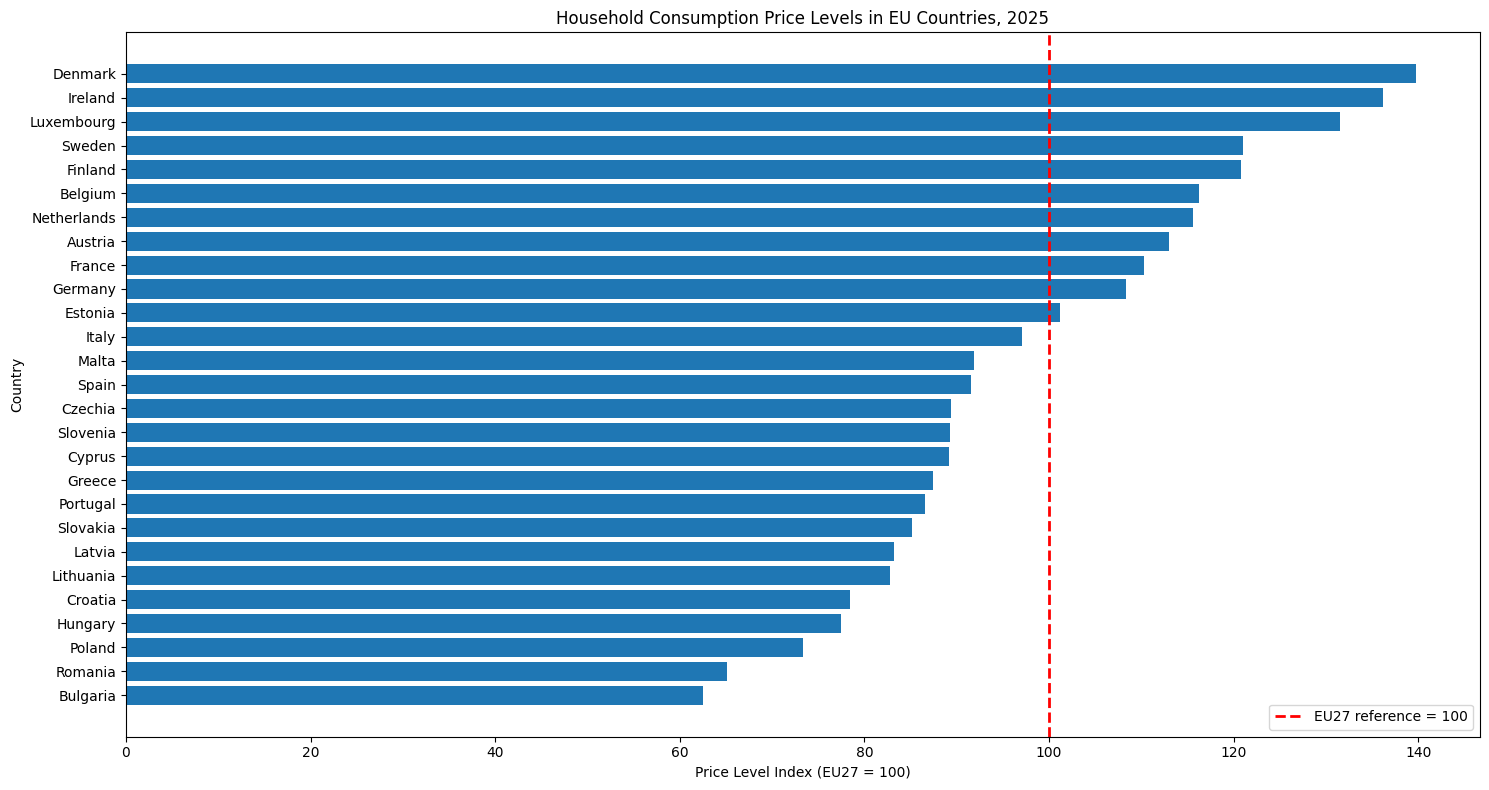

In [122]:
df_pli_countries_sorted = df_pli_countries.sort_values(VALUE_COL, ascending=True)

plot_ranked_bar(
    categories=df_pli_countries_sorted[COUNTRY_NAME_COL],
    values=df_pli_countries_sorted[VALUE_COL],
    xlabel="Price Level Index (EU27 = 100)",
    ylabel="Country",
    title="Household Consumption Price Levels in EU Countries, 2025",
    reference_line=100,
    reference_label="EU27 reference = 100",
)

### 2.5 Analytics: spread between the cheapest and most expensive country

In [123]:
min_pli = df_pli_countries[VALUE_COL].min()
max_pli = df_pli_countries[VALUE_COL].max()

lowest_pli_country = df_pli_countries.loc[df_pli_countries[VALUE_COL].idxmin(), COUNTRY_NAME_COL]
highest_pli_country = df_pli_countries.loc[df_pli_countries[VALUE_COL].idxmax(), COUNTRY_NAME_COL]

# How much pricier the most expensive country is, relative to the cheapest (cheapest as the base)
spread_from_min = (max_pli - min_pli) / min_pli * 100
# How much cheaper the cheapest country is, relative to the most expensive (most expensive as the base)
spread_from_max = (max_pli - min_pli) / max_pli * 100

print(f"Lowest PLI:  {lowest_pli_country} ({min_pli:.1f})")
print(f"Highest PLI: {highest_pli_country} ({max_pli:.1f})")
print(f"The most expensive country is {spread_from_min:.1f}% pricier than the cheapest.")
print(f"The cheapest country is {spread_from_max:.1f}% cheaper than the most expensive.")

Lowest PLI:  Bulgaria (62.5)
Highest PLI: Denmark (139.7)
The most expensive country is 123.5% pricier than the cheapest.
The cheapest country is 55.3% cheaper than the most expensive.


### 2.6 Conclusions — PLI dataset

- 27 EU countries, EU27 reference retained separately
- No duplicate country observations, no missing PLI values
- Consistent year, indicator and expenditure category throughout
- See the printed summary above for the cheapest/most expensive country and the spread between them


## 3. Net earnings — 100% of national average

### 3.1 Load raw data

In [124]:
list_raw_files(RAW_DATA_DIR)

earn_nt_net_earnings_euro.csv - 5881 bytes
earn_nt_net__earnings_50.csv - 5817 bytes
eurostat_prc_ppp_ind_1_2025_pli_e011.csv - 9879 bytes


In [125]:
earnings_100_file_path = RAW_DATA_DIR / "earn_nt_net_earnings_euro.csv"

# df_earnings_100_raw: annual net earnings (EUR) at 100% of the national average wage, one row per geo
df_earnings_100_raw = load_csv_with_preview(earnings_100_file_path)

STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,currency,Currency,estruct,Earnings structure,ecase,Earnings case,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,AT,Austria,2025,,36797.90,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,BE,Belgium,2025,,34642.30,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person without children earning 100% of the average earning,BG,Bulgaria,2025,,13016.65,,,,,
dataflow,ESTAT:EARN_NT_NET(1.0),Annual net earnings,A,Annual,EUR,Euro,NET,Net earning,P1_NCH_AW100,Single person w

In [126]:
df_earnings_100_raw.shape

(28, 21)

In [127]:
df_earnings_100_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               28 non-null     object 
 1   STRUCTURE_ID                            28 non-null     object 
 2   STRUCTURE_NAME                          28 non-null     object 
 3   freq                                    28 non-null     object 
 4   Time frequency                          28 non-null     object 
 5   currency                                28 non-null     object 
 6   Currency                                28 non-null     object 
 7   estruct                                 28 non-null     object 
 8   Earnings structure                      28 non-null     object 
 9   ecase                                   28 non-null     object 
 10  Earnings case                           28 non-null     object 


In [128]:
df_earnings_100_raw[[GEO_COL, COUNTRY_NAME_COL, VALUE_COL]]

,geo,Geopolitical entity (reporting),OBS_VALUE
0,AT,Austria,36797.90
1,BE,Belgium,34642.30
2,BG,Bulgaria,13016.65
3,CY,Cyprus,23524.01
4,CZ,Czechia,19568.67
5,DE,Germany,31000.48
6,DK,Denmark,41981.24
7,EE,Estonia,20044.71
8,EL,Greece,15049.76
9,ES,Spain,25262.74


### 3.2 Data validation / quality check

In [129]:
df_earnings_100_raw.columns.tolist()

['STRUCTURE',
 'STRUCTURE_ID',
 'STRUCTURE_NAME',
 'freq',
 'Time frequency',
 'currency',
 'Currency',
 'estruct',
 'Earnings structure',
 'ecase',
 'Earnings case',
 'geo',
 'Geopolitical entity (reporting)',
 'TIME_PERIOD',
 'Time',
 'OBS_VALUE',
 'Observation value',
 'OBS_FLAG',
 'Observation status (Flag) V2 structure',
 'CONF_STATUS',
 'Confidentiality status (flag)']

In [130]:
check_data_quality(df_earnings_100_raw, id_col=GEO_COL, value_col=VALUE_COL)

Duplicate 'geo' values: 0
Missing 'OBS_VALUE' values: 0


In [131]:
df_earnings_100_raw["TIME_PERIOD"].unique()

array([2025])

In [132]:
df_earnings_100_raw["Earnings structure"].unique()

array(['Net earning'], dtype=object)

In [133]:
df_earnings_100_raw["Earnings case"].unique()

array(['Single person without children earning 100% of the average earning'],
      dtype=object)

In [134]:
df_earnings_100_raw["currency"].unique()

array(['EUR'], dtype=object)

### 3.3 Descriptive statistics

In [135]:
df_earnings_100_raw[VALUE_COL].describe()

count       28.000000
mean     25866.062500
std      10601.669596
min      12967.220000
25%      17140.220000
50%      23997.640000
75%      33886.872500
max      54259.930000
Name: OBS_VALUE, dtype: float64

In [136]:
# eu27_earnings_100: EU27 average net earnings (EUR) at 100% of national average wage — used
# throughout as the reference point for indices below
eu27_earnings_100 = get_reference_value(df_earnings_100_raw, GEO_COL, EU27_CODE, VALUE_COL)

# df_earnings_100_countries: the 27 member states only, excluding the EU27 aggregate row
df_earnings_100_countries = exclude_geo_codes(df_earnings_100_raw, [EU27_CODE])

print(f"EU27 average net earnings (100%): €{eu27_earnings_100:,.2f}")
df_earnings_100_countries[VALUE_COL].describe()

EU27 average net earnings (100%): €26,928.97


count       27.000000
mean     25826.695556
std      10801.538594
min      12967.220000
25%      17024.370000
50%      23524.010000
75%      34132.705000
max      54259.930000
Name: OBS_VALUE, dtype: float64

### 3.4 Merge PLI and earnings

In [137]:
set(df_pli_countries[GEO_COL]) == set(df_earnings_100_countries[GEO_COL])  # confirm both datasets cover the same 27 countries

True

In [138]:
pli_for_merge = df_pli_countries[[GEO_COL, COUNTRY_NAME_COL, VALUE_COL]].rename(columns={VALUE_COL: "pli"})
earnings_100_for_merge = df_earnings_100_countries[[GEO_COL, VALUE_COL]].rename(columns={VALUE_COL: "net_earnings_eur"})

# df_merged_100: one row per country with PLI and 100%-of-average net earnings side by side
df_merged_100 = pli_for_merge.merge(earnings_100_for_merge, on=GEO_COL, how="inner")
# how="inner" keeps only geo codes present in both datasets;
# use "left"/"right" to keep everything from one side, or "outer" to keep everything from both
df_merged_100.shape

(27, 4)

In [139]:
df_merged_100.head()

,geo,Geopolitical entity (reporting),pli,net_earnings_eur
0,AT,Austria,113.0,36797.90
1,BE,Belgium,116.2,34642.30
2,BG,Bulgaria,62.5,13016.65
3,CY,Cyprus,89.2,23524.01
4,CZ,Czechia,89.4,19568.67


### 3.5 Plots and stats — are higher-earning countries also higher-priced?

NameError: name 'fit_linear_regression' is not defined

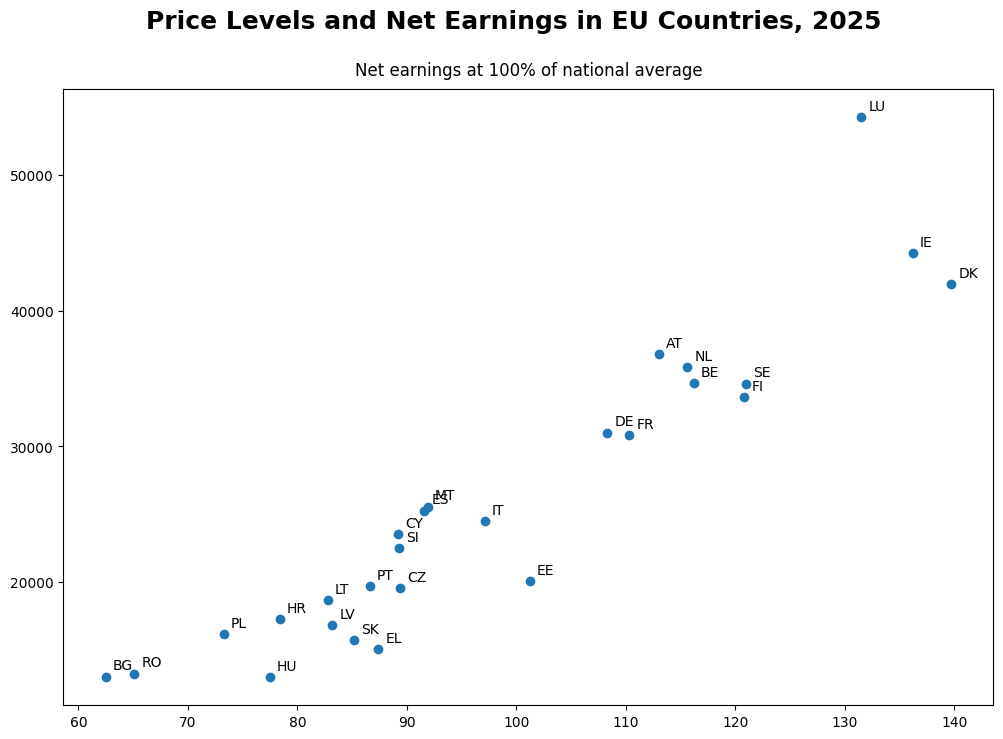

In [140]:
regression_100 = plot_scatter_with_trend(
    df_merged_100,
    x_col="pli",
    y_col="net_earnings_eur",
    label_col=GEO_COL,
    xlabel="Price Level Index (EU27 = 100)",
    ylabel="Annual net earnings (€)",
    title="Price Levels and Net Earnings in EU Countries, 2025",
    subtitle="Net earnings at 100% of national average",
    eu27_y=eu27_earnings_100,
    eu27_y_label=f"EU27 net earnings = €{eu27_earnings_100:,.2f}",
)

correlation_100 = regression_100["correlation"]
r_squared_100 = regression_100["r_squared"]
print(f"Pearson correlation: {correlation_100:.3f}")
print(f"R-squared: {r_squared_100:.3f}")

### 3.6 Residual analysis

Which countries earn more (or less) than their price level alone would predict?

In [ ]:
df_merged_100["predicted_earnings"] = regression_100["predicted"]
df_merged_100["earnings_residual"] = regression_100["residuals"]
print("earnings_residual(i) = net_earnings_eur(i) - predicted_earnings(i)")

df_merged_100.sort_values("earnings_residual", ascending=False)[
    [GEO_COL, "pli", "net_earnings_eur", "predicted_earnings", "earnings_residual"]
]

earnings_residual(i) = net_earnings_eur(i) - predicted_earnings(i)


,geo,pli,net_earnings_eur,predicted_earnings,earnings_residual
17,LU,131.5,54259.93,42029.013494,12230.916506
2,BG,62.5,13016.65,8719.679661,4296.970339
0,AT,113.0,36797.90,33098.250075,3699.649925
23,RO,65.1,13232.74,9974.813979,3257.926021
19,MT,91.9,25543.95,22912.352338,2631.597662
9,ES,91.6,25262.74,22767.529147,2495.210853
21,PL,73.3,16163.12,13933.314522,2229.805478
3,CY,89.2,23524.01,21608.943623,1915.066377
20,NL,115.6,35836.93,34353.384393,1483.545607
12,HR,78.4,17256.07,16395.308762,860.761238


### 3.7 Affordability index

In [ ]:
df_merged_100 = compute_affordability_index(
    df_merged_100, pli_col="pli", earnings_col="net_earnings_eur", eu27_earnings=eu27_earnings_100
)

df_merged_100.sort_values("affordability_index", ascending=True)[
    [GEO_COL, "pli", "net_earnings_eur", "earnings_to_pli", "affordability_index"]
]

,geo,pli,net_earnings_eur,earnings_to_pli,affordability_index
13,HU,77.5,12967.22,167.318968,62.133445
8,EL,87.4,15049.76,172.194050,63.943794
26,SK,85.2,15685.92,184.107042,68.367651
7,EE,101.2,20044.71,198.070257,73.552853
18,LV,83.2,16792.67,201.834976,74.950871
23,RO,65.1,13232.74,203.267896,75.482982
2,BG,62.5,13016.65,208.266400,77.339163
4,CZ,89.4,19568.67,218.888926,81.283809
12,HR,78.4,17256.07,220.102934,81.734628
21,PL,73.3,16163.12,220.506412,81.884458


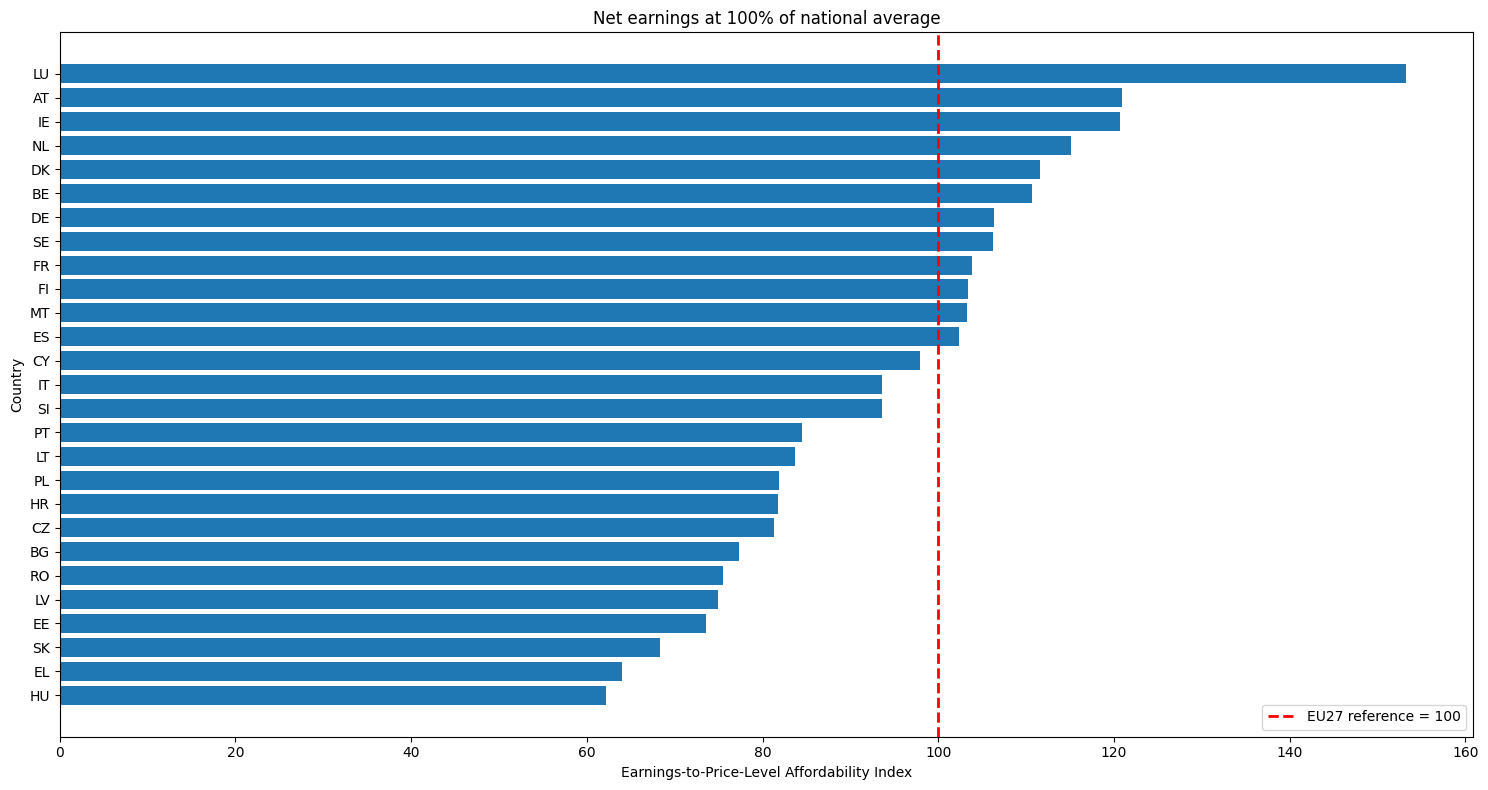

In [ ]:
df_affordability_100_sorted = df_merged_100.sort_values("affordability_index", ascending=True)

plot_ranked_bar(
    categories=df_affordability_100_sorted[GEO_COL],
    values=df_affordability_100_sorted["affordability_index"],
    xlabel="Earnings-to-Price-Level Affordability Index",
    ylabel="Country",
    title="Net earnings at 100% of national average",
    reference_line=100,
    reference_label="EU27 reference = 100",
)

## 4. Net earnings — 50% of national average

Same pipeline as Section 3, applied to earners at 50% of the national average wage, so we can see
whether affordability patterns hold up for lower incomes too.

### 4.1 Load raw data

In [ ]:
earnings_50_file_path = RAW_DATA_DIR / "earn_nt_net__earnings_50.csv"

# df_earnings_50_raw: annual net earnings (EUR) at 50% of the national average wage, one row per geo
df_earnings_50_raw = pd.read_csv(earnings_50_file_path)
df_earnings_50_raw.shape

(28, 21)

In [ ]:
df_earnings_50_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   STRUCTURE                               28 non-null     object 
 1   STRUCTURE_ID                            28 non-null     object 
 2   STRUCTURE_NAME                          28 non-null     object 
 3   freq                                    28 non-null     object 
 4   Time frequency                          28 non-null     object 
 5   currency                                28 non-null     object 
 6   Currency                                28 non-null     object 
 7   estruct                                 28 non-null     object 
 8   Earnings structure                      28 non-null     object 
 9   ecase                                   28 non-null     object 
 10  Earnings case                           28 non-null     object 


### 4.2 Descriptive statistics

In [ ]:
df_earnings_50_raw[VALUE_COL].describe()

count       28.000000
mean     15922.270714
std       7746.099165
min       6483.610000
25%       9549.527500
50%      14252.450000
75%      19814.222500
max      36112.840000
Name: OBS_VALUE, dtype: float64

In [ ]:
# eu27_earnings_50: EU27 average net earnings (EUR) at 50% of national average wage
eu27_earnings_50 = get_reference_value(df_earnings_50_raw, GEO_COL, EU27_CODE, VALUE_COL)

# df_earnings_50_countries: the 27 member states only, excluding the EU27 aggregate row
df_earnings_50_countries = exclude_geo_codes(df_earnings_50_raw, [EU27_CODE])

print(f"EU27 average net earnings (50%): €{eu27_earnings_50:,.2f}")
df_earnings_50_countries.shape

EU27 average net earnings (50%): €16,722.37


(27, 21)

In [ ]:
df_earnings_50_countries[[GEO_COL, COUNTRY_NAME_COL, VALUE_COL]].sort_values(VALUE_COL)

,geo,Geopolitical entity (reporting),OBS_VALUE
14,HU,Hungary,6483.61
2,BG,Bulgaria,6508.32
24,RO,Romania,6741.43
27,SK,Slovakia,8389.57
8,EL,Greece,8650.50
19,LV,Latvia,9176.64
22,PL,Poland,9370.90
13,HR,Croatia,9609.07
17,LT,Lithuania,10771.32
7,EE,Estonia,11748.91


### 4.3 Merge with PLI

In [ ]:
earnings_50_for_merge = df_earnings_50_countries[[GEO_COL, VALUE_COL]].rename(columns={VALUE_COL: "net_earnings_50_eur"})

# df_merged_50: one row per country with PLI and 50%-of-average net earnings side by side
df_merged_50 = df_merged_100[[GEO_COL, "pli"]].merge(earnings_50_for_merge, on=GEO_COL, how="inner")
df_merged_50.shape

(27, 3)

### 4.4 Plot: earnings vs. PLI at 50% of average earnings

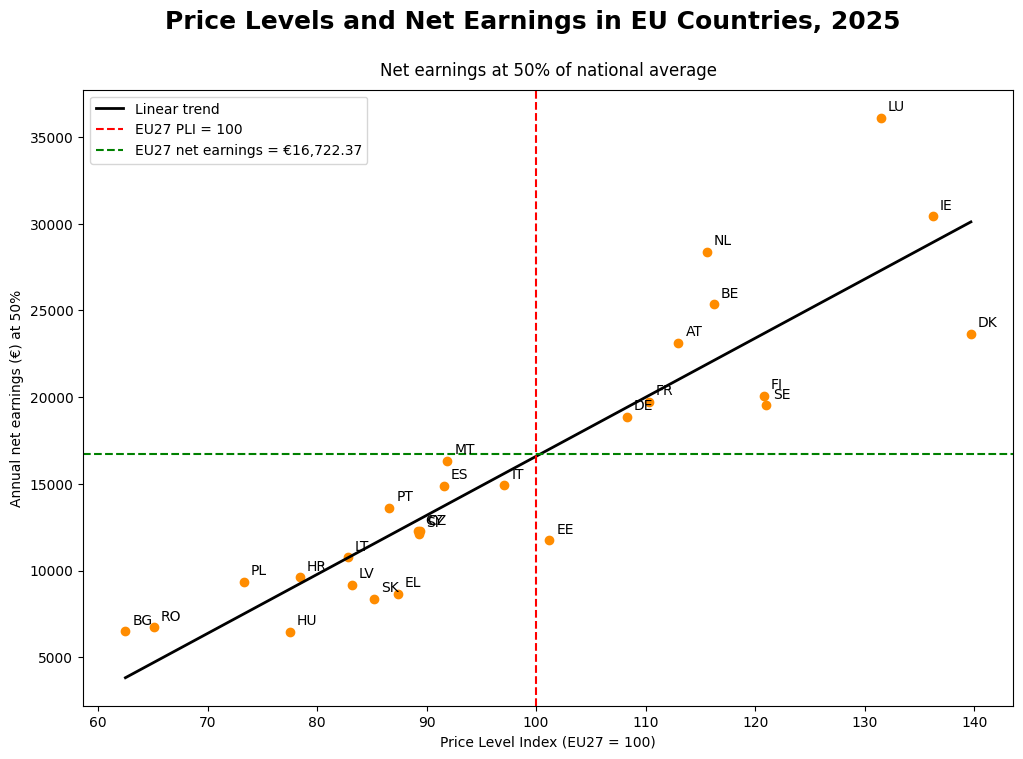

Pearson correlation: 0.904
R-squared: 0.817


In [ ]:
regression_50 = plot_scatter_with_trend(
    df_merged_50,
    x_col="pli",
    y_col="net_earnings_50_eur",
    label_col=GEO_COL,
    xlabel="Price Level Index (EU27 = 100)",
    ylabel="Annual net earnings (€) at 50%",
    title="Price Levels and Net Earnings in EU Countries, 2025",
    subtitle="Net earnings at 50% of national average",
    eu27_y=eu27_earnings_50,
    eu27_y_label=f"EU27 net earnings = €{eu27_earnings_50:,.2f}",
    color="darkorange",
)

correlation_50 = regression_50["correlation"]
r_squared_50 = regression_50["r_squared"]
print(f"Pearson correlation: {correlation_50:.3f}")
print(f"R-squared: {r_squared_50:.3f}")

### 4.5 Residual analysis

In [ ]:
df_merged_50["predicted_earnings_50"] = regression_50["predicted"]
df_merged_50["earnings_residual_50"] = regression_50["residuals"]

### 4.6 Affordability index (50%)

In [ ]:
df_merged_50 = compute_affordability_index(
    df_merged_50, pli_col="pli", earnings_col="net_earnings_50_eur", eu27_earnings=eu27_earnings_50, suffix="_50"
)

df_merged_50.sort_values("affordability_index_50", ascending=True)[
    [GEO_COL, "pli", "net_earnings_50_eur", "earnings_to_pli_50", "affordability_index_50"]
]

,geo,pli,net_earnings_50_eur,earnings_to_pli_50,affordability_index_50
13,HU,77.5,6483.61,83.659484,50.028485
26,SK,85.2,8389.57,98.469131,58.884675
8,EL,87.4,8650.50,98.975973,59.187766
23,RO,65.1,6741.43,103.554992,61.926026
2,BG,62.5,6508.32,104.133120,62.271747
18,LV,83.2,9176.64,110.296154,65.957250
7,EE,101.2,11748.91,116.095949,69.425535
12,HR,78.4,9609.07,122.564668,73.293838
21,PL,73.3,9370.90,127.843111,76.450354
16,LT,82.8,10771.32,130.088406,77.793044


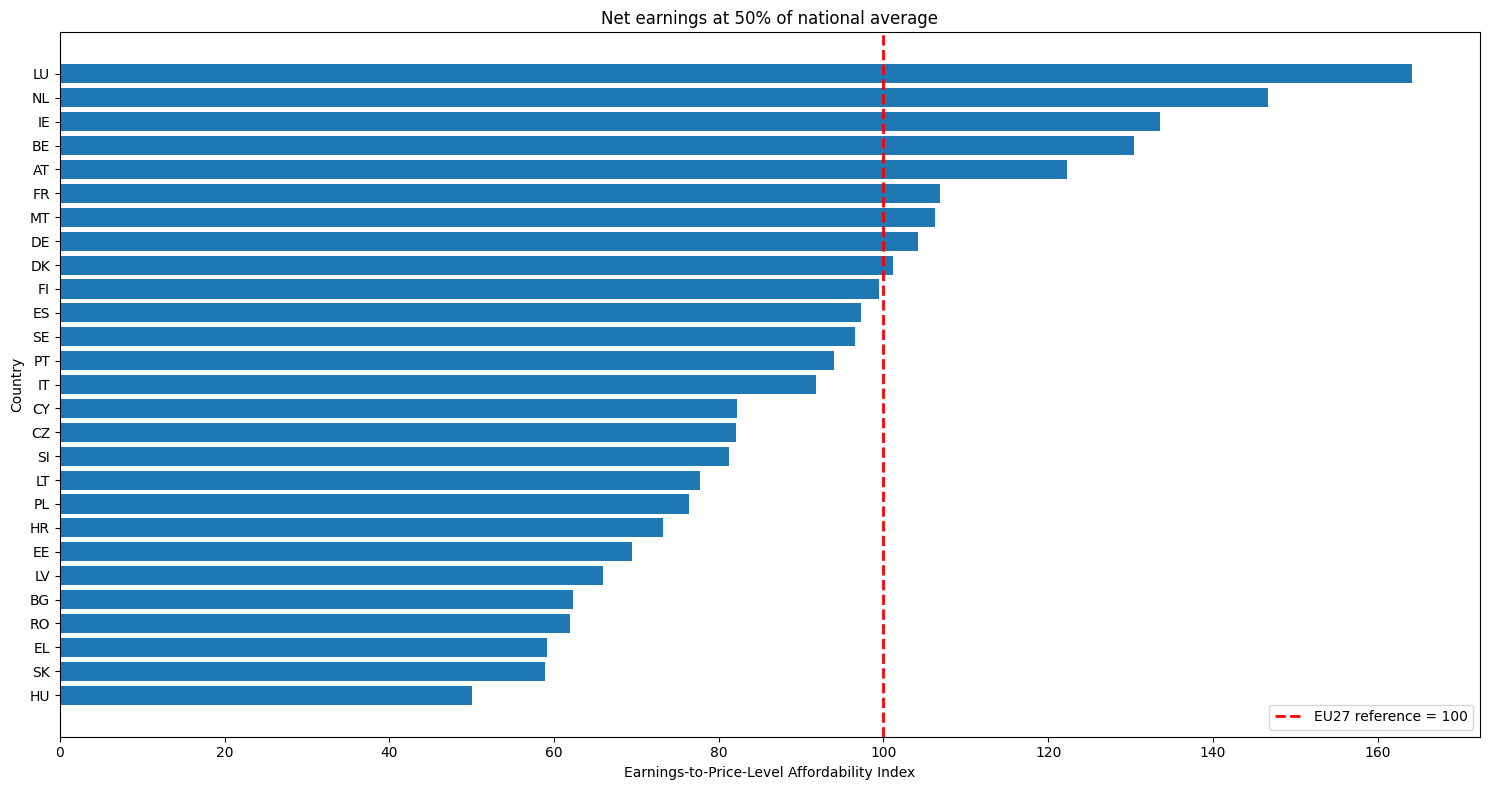

In [ ]:
df_affordability_50_sorted = df_merged_50.sort_values("affordability_index_50", ascending=True)

plot_ranked_bar(
    categories=df_affordability_50_sorted[GEO_COL],
    values=df_affordability_50_sorted["affordability_index_50"],
    xlabel="Earnings-to-Price-Level Affordability Index",
    ylabel="Country",
    title="Net earnings at 50% of national average",
    reference_line=100,
    reference_label="EU27 reference = 100",
)

## 5. Comparing affordability at 100% vs. 50% of average earnings

In [ ]:
# df_comparison: one row per country with both the 100%-earner and 50%-earner metrics side by side
df_comparison = df_merged_100.merge(
    df_merged_50.drop(columns=["pli"]),  # "pli" is identical in both frames, so drop the duplicate before merging
    on=GEO_COL,
    how="inner",
)

df_comparison["affordability_change"] = (
    df_comparison["affordability_index_50"] - df_comparison["affordability_index"]
)

df_comparison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   geo                              27 non-null     object 
 1   Geopolitical entity (reporting)  27 non-null     object 
 2   pli                              27 non-null     float64
 3   net_earnings_eur                 27 non-null     float64
 4   predicted_earnings               27 non-null     float64
 5   earnings_residual                27 non-null     float64
 6   earnings_index                   27 non-null     float64
 7   earnings_to_pli                  27 non-null     float64
 8   affordability_index              27 non-null     float64
 9   net_earnings_50_eur              27 non-null     float64
 10  predicted_earnings_50            27 non-null     float64
 11  earnings_residual_50             27 non-null     float64
 12  earnings_index_50       

In [ ]:
df_comparison[
    [GEO_COL, "affordability_index", "affordability_index_50", "affordability_change"]
].sort_values("affordability_change", ascending=False)

,geo,affordability_index,affordability_index_50,affordability_change
20,NL,115.120647,146.756155,31.635508
1,BE,110.708470,130.438403,19.729934
14,IE,120.683234,133.623184,12.939950
17,LU,153.226448,164.224543,10.998095
22,PT,84.512082,93.968939,9.456857
11,FR,103.800826,106.920583,3.119757
19,MT,103.217373,106.243108,3.025735
0,AT,120.927437,122.340706,1.413269
4,CZ,81.283809,82.127727,0.843918
15,IT,93.587433,91.844818,-1.742615


### Plot: dumbbell chart of affordability at 100% vs 50%

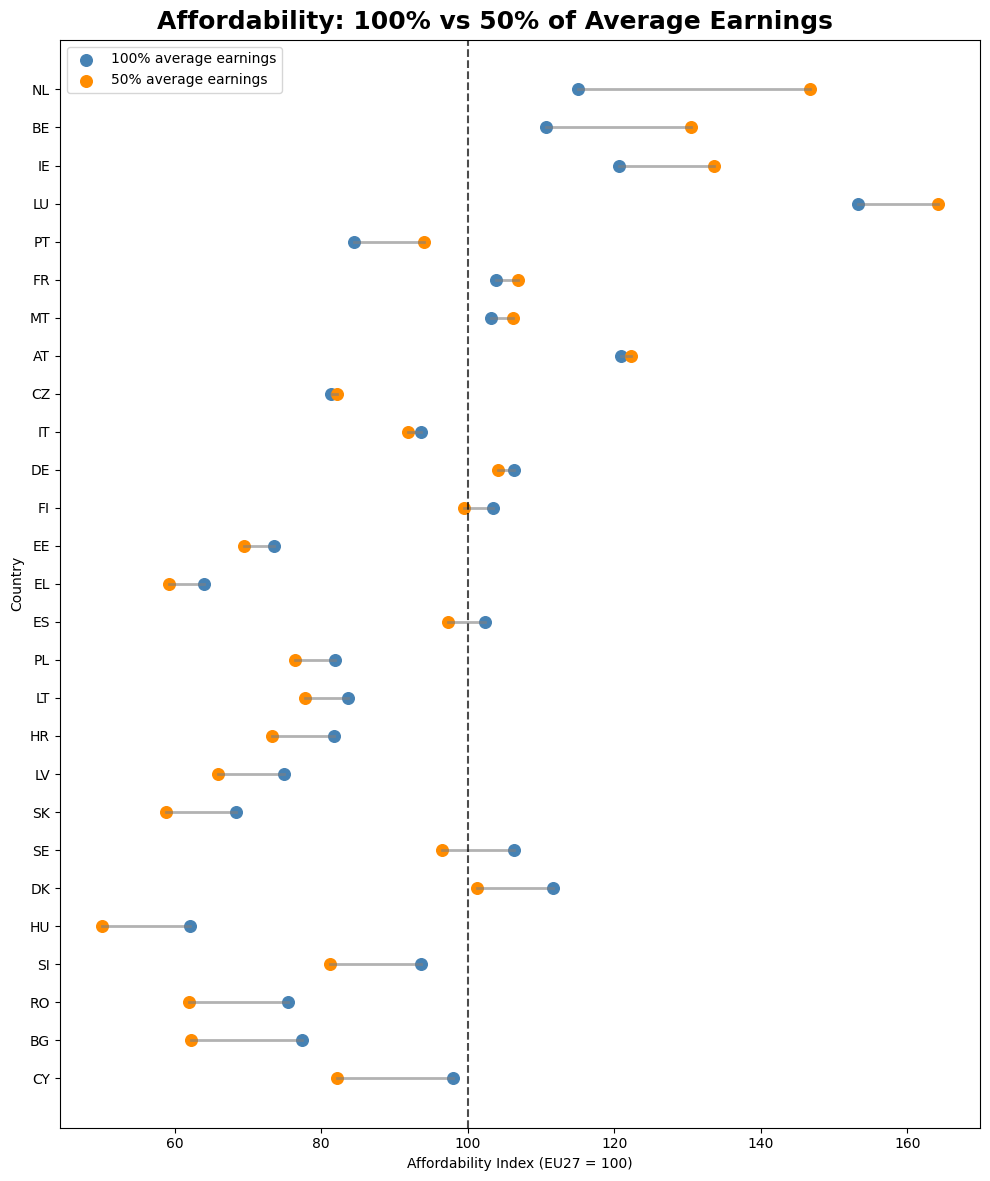

In [ ]:
df_comparison_sorted = df_comparison.sort_values("affordability_change").copy()

fig, ax = plt.subplots(figsize=(10, 12))
fig.suptitle("Affordability: 100% vs 50% of Average Earnings", fontsize=18, fontweight="bold")

y_positions = range(len(df_comparison_sorted))

for i, (_, row) in enumerate(df_comparison_sorted.iterrows()):
    # Connecting line between the two scenarios for this country
    ax.plot(
        [row["affordability_index"], row["affordability_index_50"]],
        [i, i],
        color="gray", linewidth=2, alpha=0.6,
    )
    ax.scatter(
        row["affordability_index"], i, color="steelblue", s=70,
        label="100% average earnings" if i == 0 else "",
    )
    ax.scatter(
        row["affordability_index_50"], i, color="darkorange", s=70,
        label="50% average earnings" if i == 0 else "",
    )

ax.set_yticks(list(y_positions))
ax.set_yticklabels(df_comparison_sorted[GEO_COL])
ax.axvline(100, color="black", linestyle="--", linewidth=1.5, alpha=0.7)  # EU27 benchmark

ax.set_xlabel("Affordability Index (EU27 = 100)")
ax.set_ylabel("Country")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Export processed data

In [ ]:
PROCESSED_DATA_DIR.mkdir(exist_ok=True)
output_path = PROCESSED_DATA_DIR / "eu27_earnings_affordability_final.csv"

df_comparison.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

Saved: ..\data\processed\eu27_earnings_affordability_final.csv
